# **Day 54: Gaussian Processes**
*Module 9 - Probabilistic ML, Time Series and Semi-Supervised Learning*

A **Gaussian process (GP)** is a probability distribution over **functions**. Instead of choosing a parametric form, we specify how similar function values should be at nearby inputs (the **kernel**). Given data, the GP gives a predictive **mean and uncertainty everywhere**. GPs power Bayesian optimisation (Day 41), surrogate models of expensive simulators, and **kriging** in geostatistics (GP regression in space).

> A Gaussian process is a flexible model that predicts a whole distribution at every point: a best guess plus an uncertainty band that widens far from the data. It is closely related to kriging in geostatistics.
>
> *Example:* Interpolating rainfall between weather stations gives narrow uncertainty near stations and wide uncertainty in the gaps between them.

In [1]:
import numpy as np
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)   # harmless numerical warnings (see text)
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor, GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF, Matern, ExpSineSquared, RationalQuadratic, WhiteKernel, ConstantKernel as C, DotProduct
rng = np.random.default_rng(54)

## **1. A Distribution Over Functions**
$f\sim\mathcal{GP}(m(x), k(x, x'))$ means: for any finite set of inputs, the function values are jointly Gaussian with covariance $K_{ij} = k(x_i, x_j)$.

RBF kernel: $k(x,x') = \sigma^2\exp\left(-\frac{(x-x')^2}{2\ell^2}\right)$; the **length scale** $\ell$ controls how quickly the function varies.

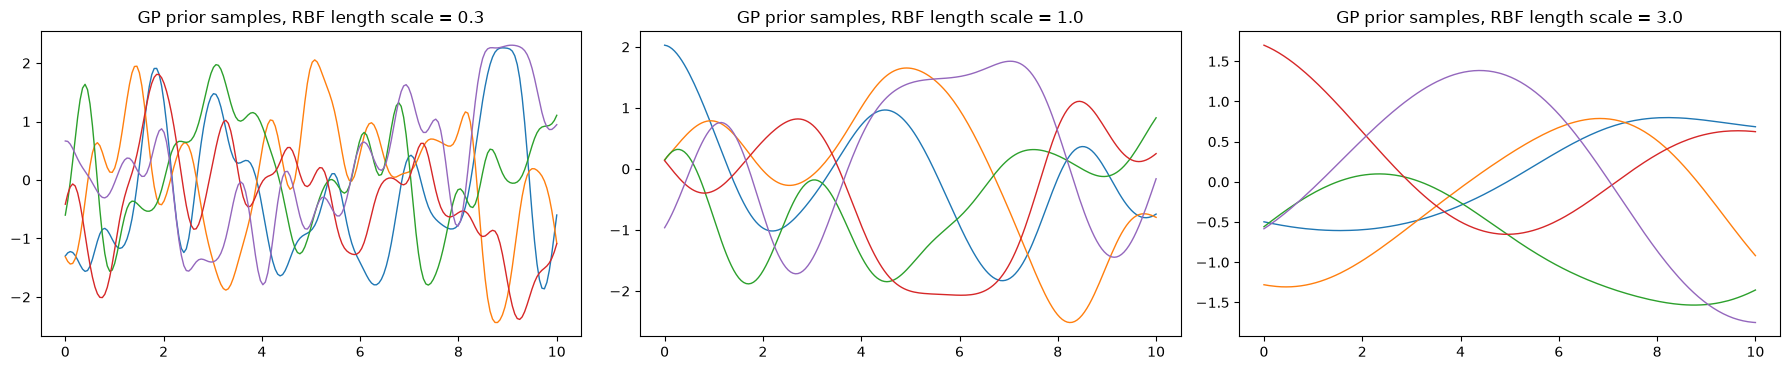

In [2]:
def rbf(a, b, ell=1.0, sigma=1.0):
    return sigma ** 2 * np.exp(-0.5 * (a[:, None] - b[None, :]) ** 2 / ell ** 2)

x = np.linspace(0, 10, 200)
fig, axes = plt.subplots(1, 3, figsize=(18, 3.8))
for ax, ell in zip(axes, [0.3, 1.0, 3.0]):
    K = rbf(x, x, ell) + 1e-8 * np.eye(len(x))
    for f in rng.multivariate_normal(np.zeros(len(x)), K, 5):
        ax.plot(x, f, lw=1)
    ax.set_title(f"GP prior samples, RBF length scale = {ell}")
plt.tight_layout(); plt.show()

## **2. GP Regression From Scratch**
With observations $\mathbf y = f(X) + \varepsilon$, $\varepsilon\sim\mathcal N(0,\sigma_n^2)$, the posterior at test points $X_*$ is Gaussian with
$$\boldsymbol\mu_* = K_*^\top(K + \sigma_n^2I)^{-1}\mathbf y,\qquad \Sigma_* = K_{**} - K_*^\top(K+\sigma_n^2I)^{-1}K_*$$
(computed stably with a Cholesky factorisation).

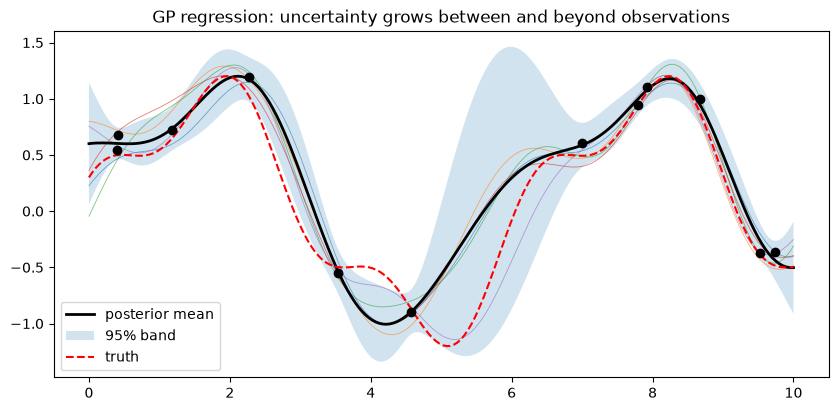

In [3]:
def gp_posterior(X_train, y_train, X_test, ell=1.0, sigma=1.0, noise=0.1):
    K = rbf(X_train, X_train, ell, sigma) + noise ** 2 * np.eye(len(X_train))
    Ks = rbf(X_train, X_test, ell, sigma); Kss = rbf(X_test, X_test, ell, sigma)
    L = np.linalg.cholesky(K)
    alpha = np.linalg.solve(L.T, np.linalg.solve(L, y_train))
    mu = Ks.T @ alpha
    v = np.linalg.solve(L, Ks); cov = Kss - v.T @ v
    log_ml = -0.5 * y_train @ alpha - np.log(np.diag(L)).sum() - 0.5 * len(X_train) * np.log(2 * np.pi)
    return mu, cov, log_ml

f_true = lambda t: np.sin(t) + 0.3 * np.cos(3 * t)
X_tr = np.sort(rng.uniform(0, 10, 12)); y_tr = f_true(X_tr) + rng.normal(0, 0.1, 12)
mu, cov, lml = gp_posterior(X_tr, y_tr, x, ell=1.0)
sd = np.sqrt(np.clip(np.diag(cov), 0, None))
plt.figure(figsize=(10, 4.5))
for s in rng.multivariate_normal(mu, cov + 1e-8 * np.eye(len(x)), 5): plt.plot(x, s, lw=0.6, alpha=0.6)
plt.plot(x, mu, "k", lw=2, label="posterior mean"); plt.fill_between(x, mu - 2 * sd, mu + 2 * sd, alpha=0.2, label="95% band")
plt.plot(x, f_true(x), "r--", label="truth"); plt.scatter(X_tr, y_tr, c="k", zorder=3)
plt.legend(); plt.title("GP regression: uncertainty grows between and beyond observations"); plt.show()

## **3. Choosing Hyperparameters: The Marginal Likelihood**
The log marginal likelihood $\log p(\mathbf y\mid X,\theta)$ automatically trades data fit against complexity (Occam's razor). Maximise it over the length scale and noise.

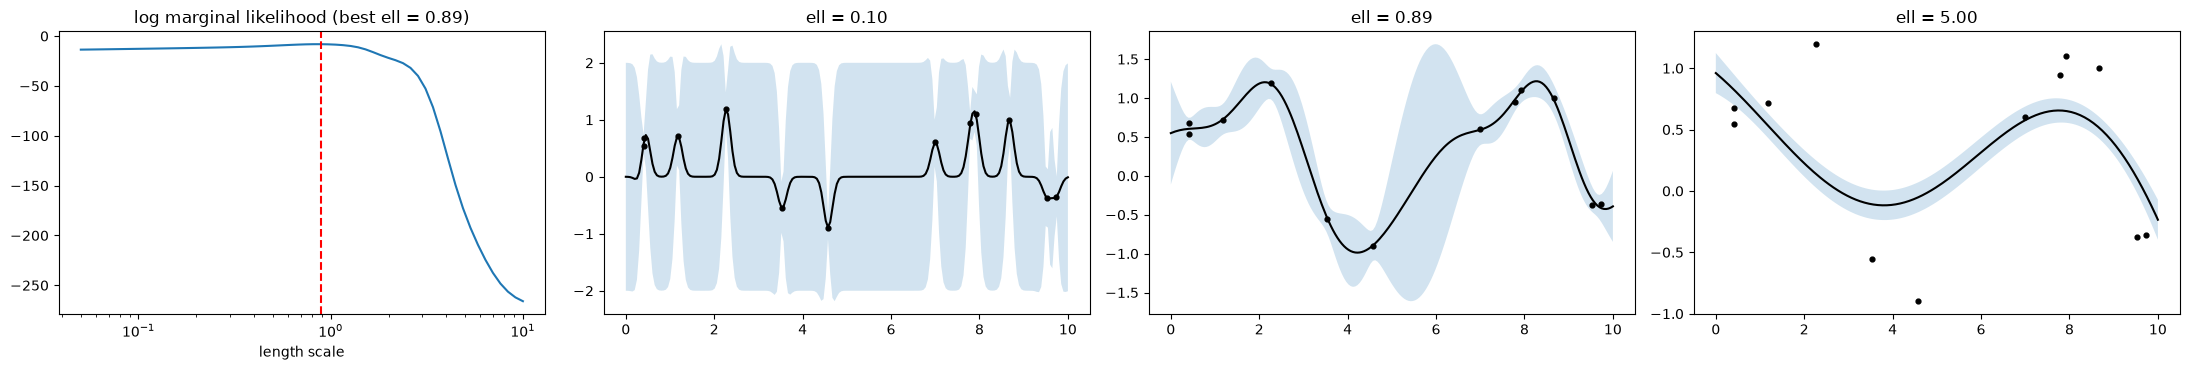

In [4]:
ells = np.logspace(-1.3, 1, 60)
lmls = [gp_posterior(X_tr, y_tr, x, ell=e)[2] for e in ells]
best_ell = ells[np.argmax(lmls)]
fig, axes = plt.subplots(1, 4, figsize=(22, 3.8))
axes[0].semilogx(ells, lmls); axes[0].axvline(best_ell, c="r", ls="--"); axes[0].set(title=f"log marginal likelihood (best ell = {best_ell:.2f})", xlabel="length scale")
for ax, e in zip(axes[1:], [0.1, best_ell, 5.0]):
    m_, c_, _ = gp_posterior(X_tr, y_tr, x, ell=e); s_ = np.sqrt(np.clip(np.diag(c_), 0, None))
    ax.plot(x, m_, "k"); ax.fill_between(x, m_ - 2 * s_, m_ + 2 * s_, alpha=0.2); ax.scatter(X_tr, y_tr, c="k", s=12); ax.set_title(f"ell = {e:.2f}")
plt.tight_layout(); plt.show()

## **4. Kernels and Kernel Algebra**

| Kernel | Encodes | sklearn |
|---|---|---|
| RBF | very smooth functions | `RBF(length_scale)` |
| Matern ($\nu$ = 1/2, 3/2, 5/2) | rougher, more realistic for physical data | `Matern(nu=1.5)` |
| Periodic | repeating patterns (seasons, days) | `ExpSineSquared(length_scale, periodicity)` |
| Rational quadratic | mixture of length scales | `RationalQuadratic` |
| Linear | linear trends | `DotProduct` |
| White noise | measurement noise | `WhiteKernel` |

Sums model **additive** components (trend + season); products model **modulation** (a seasonal pattern whose amplitude changes).

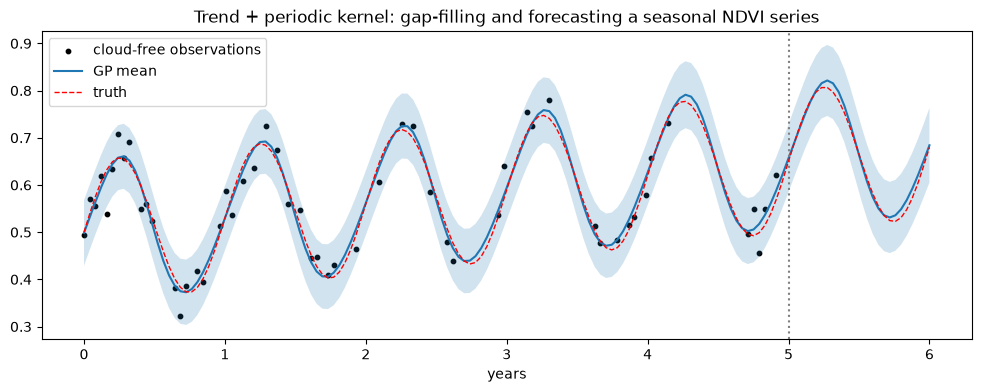

learned kernel: 2.21**2 * RBF(length_scale=9.63) + 2.46**2 * ExpSineSquared(length_scale=3.01, periodicity=1) + WhiteKernel(noise_level=0.0933)


In [5]:
t = np.linspace(0, 6, 150)                                     # 6 years of monthly-ish NDVI
ndvi = 0.5 + 0.03 * t + 0.15 * np.sin(2 * np.pi * t) + rng.normal(0, 0.03, len(t))
obs = np.sort(rng.choice(len(t), 70, replace=False)); obs = obs[t[obs] < 5]       # gaps (clouds) and nothing after year 5
kernel = (C(0.1) * RBF(5.0, length_scale_bounds=(2, 100))                                   # slow trend
          + C(0.05) * ExpSineSquared(length_scale=1.0, periodicity=1.0, length_scale_bounds=(0.3, 10), periodicity_bounds=(0.8, 1.2))   # annual cycle
          + WhiteKernel(1e-3, noise_level_bounds=(1e-5, 1e-1)))
# Bounds encode prior knowledge (a yearly cycle, a slow trend); without them the optimiser can collapse to a degenerate solution.
gp = GaussianProcessRegressor(kernel, normalize_y=True, n_restarts_optimizer=3, random_state=0).fit(t[obs, None], ndvi[obs])
m_, s_ = gp.predict(t[:, None], return_std=True)
plt.figure(figsize=(12, 4)); plt.scatter(t[obs], ndvi[obs], c="k", s=10, label="cloud-free observations")
plt.plot(t, m_, "C0", label="GP mean"); plt.fill_between(t, m_ - 2 * s_, m_ + 2 * s_, alpha=0.2); plt.axvline(5, c="grey", ls=":")
plt.plot(t, 0.5 + 0.03 * t + 0.15 * np.sin(2 * np.pi * t), "r--", lw=1, label="truth"); plt.legend(); plt.xlabel("years")
plt.title("Trend + periodic kernel: gap-filling and forecasting a seasonal NDVI series"); plt.show()
print("learned kernel:", gp.kernel_)

# **Part 2: Going Deeper - Spatial Interpolation (Kriging)**

Kriging = GP regression with spatial coordinates as inputs. Example: interpolate **soil organic carbon** measured at 80 field sites across a 10 x 10 km area, with a **map of uncertainty** (where to sample next).

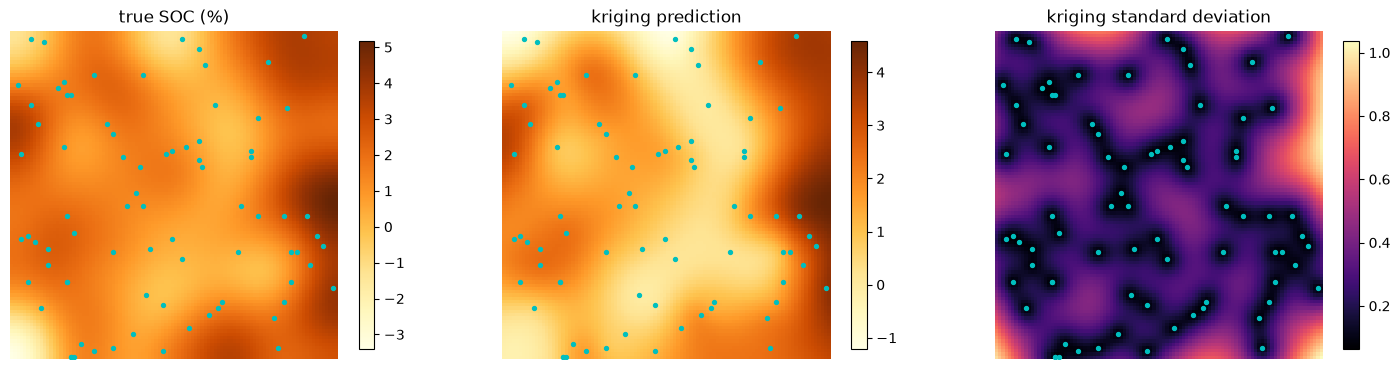

learned kernel: 1.87**2 * Matern(length_scale=3.15, nu=1.5) + WhiteKernel(noise_level=0.00286)
map RMSE 0.353 | 95% interval coverage 0.975


In [6]:
from scipy.ndimage import gaussian_filter
G = 100
field = gaussian_filter(rng.normal(size=(G, G)), 10); field = 1.5 + 1.2 * (field - field.mean()) / field.std()   # true SOC (%)
sites = rng.integers(0, G, (80, 2))
z = field[sites[:, 0], sites[:, 1]] + rng.normal(0, 0.1, 80)
coords = sites * 0.1                                                         # km
gpk = GaussianProcessRegressor(C(1.0) * Matern(length_scale=1.0, nu=1.5) + WhiteKernel(0.01), normalize_y=True, n_restarts_optimizer=3, random_state=0).fit(coords, z)
gy, gx = np.mgrid[0:G, 0:G]
pred, psd = gpk.predict(np.c_[gy.ravel(), gx.ravel()] * 0.1, return_std=True)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, img, title, cmap in [(axes[0], field, "true SOC (%)", "YlOrBr"), (axes[1], pred.reshape(G, G), "kriging prediction", "YlOrBr"), (axes[2], psd.reshape(G, G), "kriging standard deviation", "magma")]:
    im = ax.imshow(img, cmap=cmap); ax.scatter(sites[:, 1], sites[:, 0], c="c", s=8); ax.set_title(title); ax.axis("off"); fig.colorbar(im, ax=ax, shrink=0.8)
plt.show()
print("learned kernel:", gpk.kernel_)
print(f"map RMSE {np.sqrt(np.mean((pred.reshape(G, G) - field) ** 2)):.3f} | 95% interval coverage {np.mean(np.abs(pred.reshape(G, G) - field) < 1.96 * psd.reshape(G, G)):.3f}")

The uncertainty map is low near sites and high in gaps: exactly where new samples would be most valuable. The learned Matern length scale is the spatial correlation range (the **variogram range** in geostatistics).

### GP classification

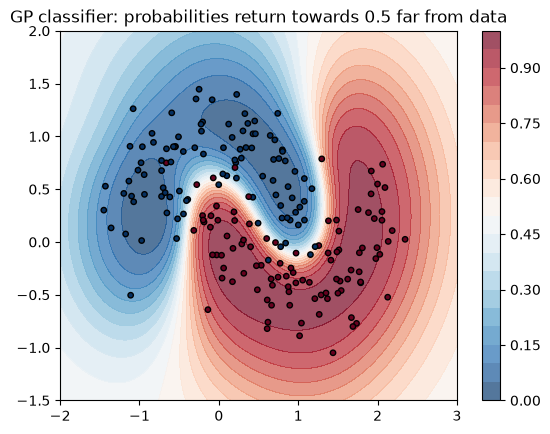

In [7]:
from sklearn.datasets import make_moons
Xm, ym = make_moons(200, noise=0.25, random_state=0)
gpc = GaussianProcessClassifier(1.0 * RBF(1.0), random_state=0).fit(Xm, ym)
xx, yy = np.meshgrid(np.linspace(-2, 3, 200), np.linspace(-1.5, 2, 200))
Pm = gpc.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1].reshape(xx.shape)
plt.contourf(xx, yy, Pm, levels=20, cmap="RdBu_r", alpha=0.7); plt.colorbar(); plt.scatter(*Xm.T, c=ym, cmap="RdBu_r", edgecolor="k", s=15)
plt.title("GP classifier: probabilities return towards 0.5 far from data"); plt.show()

### Scaling
Exact GPs cost $O(n^3)$ time and $O(n^2)$ memory: fine up to a few thousand points. For more: sparse/inducing-point GPs, local GPs, GPU libraries (GPyTorch).

## **Practice Problems**
1. Replace RBF by `Matern(nu=0.5)` in the 1-D example (sklearn). How do the posterior samples look?
2. Remove the `WhiteKernel` from the NDVI model. What happens to the fit?
3. Choose 10 new soil sampling locations where the kriging standard deviation is highest, refit with them, and report the new map RMSE.
4. *(Advanced)* Verify that `gp_posterior` matches `GaussianProcessRegressor` with a fixed kernel `RBF(1.0, length_scale_bounds="fixed") + WhiteKernel(0.01, "fixed")` (no optimisation, `normalize_y=False`).

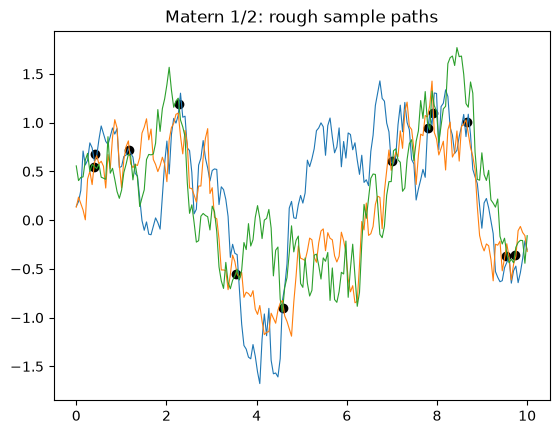

without noise term: 316**2 * RBF(length_scale=2) + 316**2 * ExpSineSquared(length_scale=0.3, periodicity=0.8) -> the model must explain the noise with the smooth kernels (it interpolates noisy points)
map RMSE with 10 extra uncertainty-targeted sites: 0.311
scratch == sklearn: True


In [8]:
# Solution 1
gpm = GaussianProcessRegressor(Matern(1.0, nu=0.5) + WhiteKernel(0.01), random_state=0).fit(X_tr[:, None], y_tr)
for s_draw in gpm.sample_y(x[:, None], 3, random_state=0).T: plt.plot(x, s_draw, lw=0.8)
plt.scatter(X_tr, y_tr, c="k"); plt.title("Matern 1/2: rough sample paths"); plt.show()
# Solution 2
gp_nonoise = GaussianProcessRegressor(C(0.1) * RBF(5.0, length_scale_bounds=(2, 100)) + C(0.05) * ExpSineSquared(1.0, 1.0, length_scale_bounds=(0.3, 10), periodicity_bounds=(0.8, 1.2)), normalize_y=True, random_state=0).fit(t[obs, None], ndvi[obs])
print("without noise term:", gp_nonoise.kernel_, "-> the model must explain the noise with the smooth kernels (it interpolates noisy points)")
# Solution 3
far = np.argsort(psd)[::-1][:10]; new_sites = np.c_[gy.ravel()[far], gx.ravel()[far]]
sites2 = np.vstack([sites, new_sites]); z2 = field[sites2[:, 0], sites2[:, 1]] + rng.normal(0, 0.1, len(sites2))
gpk2 = GaussianProcessRegressor(gpk.kernel_, normalize_y=True, optimizer=None).fit(sites2 * 0.1, z2)
print(f"map RMSE with 10 extra uncertainty-targeted sites: {np.sqrt(np.mean((gpk2.predict(np.c_[gy.ravel(), gx.ravel()] * 0.1).reshape(G, G) - field) ** 2)):.3f}")
# Solution 4
sk_gp = GaussianProcessRegressor(RBF(1.0, length_scale_bounds="fixed") + WhiteKernel(0.01, noise_level_bounds="fixed"), optimizer=None).fit(X_tr[:, None], y_tr)
print("scratch == sklearn:", np.allclose(sk_gp.predict(x[:, None]), gp_posterior(X_tr, y_tr, x, ell=1.0, noise=0.1)[0], atol=1e-6))

## **Key References**
- Rasmussen, C. E., & Williams, C. K. I. (2006). *Gaussian Processes for Machine Learning*. MIT Press (free online).
- Matheron, G. (1963). Principles of geostatistics. *Economic Geology*, 58(8), 1246-1266.
- Cressie, N. (1993). *Statistics for Spatial Data* (revised ed.). Wiley.
- Camps-Valls, G. et al. (2016). A survey on Gaussian processes for earth-observation data analysis: A comprehensive investigation. *IEEE Geoscience and Remote Sensing Magazine*, 4(2), 58-78.
- Gardner, J., Pleiss, G., Weinberger, K. Q., Bindel, D., & Wilson, A. G. (2018). GPyTorch: Blackbox matrix-matrix Gaussian process inference with GPU acceleration. *NeurIPS 31*.